# Launch Success/Failure Modeling

This notebook implements the main modeling improvements suggested by the earlier EDA and benchmarking work:

- **chronological evaluation** instead of random splits
- **richer leakage-safe maturity and cadence features** built only from prior-launch information
- **context-aware logistic modeling** via site/era interaction features

The target remains **`launch_failure_binary`**, where `1 = Not Success` and `0 = Success`.


## 1. Setup

The merged launch-weather table already contains several useful prelaunch counts and rates. This notebook extends those into a more modeling-friendly feature set while keeping the information strictly time-safe.


In [105]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier


pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data/derived")
RANDOM_STATE = 42


In [106]:
launches = pd.read_csv(DATA_DIR / "us_launch_weather_merged.csv", low_memory=False)
launches["launch_date"] = pd.to_datetime(launches["launch_date"], errors="coerce")
launches["launch_failure_binary"] = 1 - launches["launch_success_binary"]

print("Modeling sample shape:", launches.shape)
display(
    launches["launch_failure_binary"]
    .value_counts()
    .rename(index={0: "Success", 1: "Not Success"})
    .to_frame("count")
)


Modeling sample shape: (1784, 152)


,count
launch_failure_binary,
Success,1597
Not Success,187


#### What this shows

The sample is still highly imbalanced, so the modeling goal is not raw accuracy. The notebook will emphasize balanced accuracy, failure recall/F1, PR AUC, and calibration.


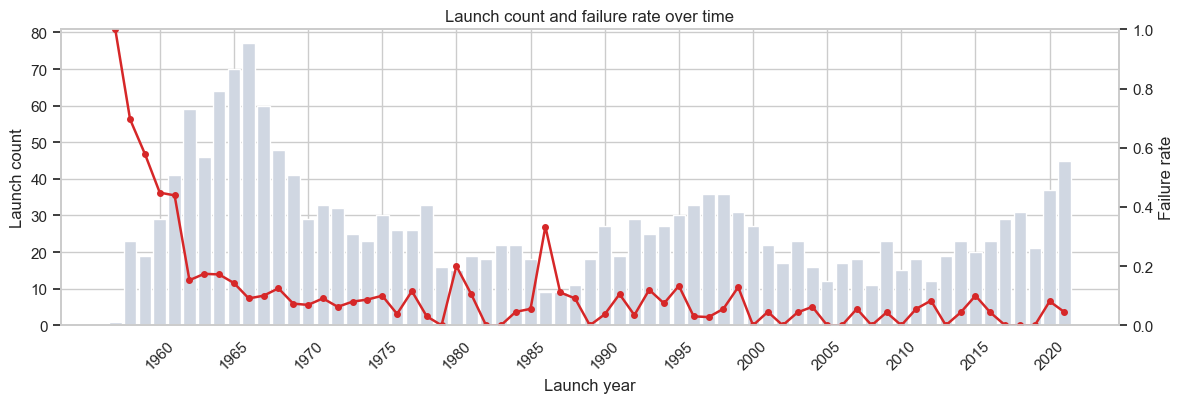

In [107]:
yearly_outcomes = (
    launches.groupby("launch_year", as_index=False)
    .agg(
        launches=("Launch Id", "count"),
        failure_rate=("launch_failure_binary", "mean"),
    )
)

fig, ax1 = plt.subplots(figsize=(12, 4.2))
ax2 = ax1.twinx()

ax1.bar(yearly_outcomes["launch_year"], yearly_outcomes["launches"], color="#d0d7e2", width=0.85)
ax2.plot(
    yearly_outcomes["launch_year"],
    yearly_outcomes["failure_rate"],
    color="#d62728",
    marker="o",
    linewidth=1.8,
    markersize=4,
)

ax1.set_title("Launch count and failure rate over time")
ax1.set_xlabel("Launch year")
ax1.set_ylabel("Launch count")
tick_years = yearly_outcomes["launch_year"]
tick_years = tick_years[tick_years % 5 == 0]
ax1.set_xticks(tick_years)
ax1.tick_params(axis="x", rotation=45)
ax2.set_ylabel("Failure rate")
ax2.set_ylim(0, min(1.0, yearly_outcomes["failure_rate"].max() * 1.08))
ax2.grid(False)

plt.tight_layout()
plt.show()


#### Why this matters

This plot frames the whole problem. The launch system is not stationary: launch activity changes over time and the **failure rate declines sharply** in later years. In context, that means a model trained on earlier decades is trying to forecast a later environment with lower baseline risk and different operational conditions. A drop in performance under chronological validation is therefore evidence of real time drift, not just weaker modeling.


## 2. Time-Safe Feature Engineering

The earlier notebooks showed that historical reliability and maturity variables are the strongest signals. The next cell expands those variables in a way that remains available before launch time.


In [108]:
df = launches.sort_values(["launch_date", "Launch Id"]).copy()

# Smooth prior success rates so low-count histories are less volatile.
for entity in ["family", "org", "config", "site"]:
    prior_launches = f"{entity}_prior_launches"
    prior_successes = f"{entity}_prior_successes"
    rate_col = f"{entity}_success_rate_prelaunch"
    df[f"{entity}_failure_rate_prelaunch"] = 1 - df[rate_col]
    df[f"{entity}_success_rate_smoothed"] = (df[prior_successes] + 1) / (df[prior_launches] + 2)
    df[f"{entity}_experience_log"] = np.log1p(df[prior_launches])
    df[f"{entity}_failure_count_log"] = np.log1p(df[prior_launches] - df[prior_successes]).clip(lower=0)
    years_since = df[f"{entity}_years_since_first_launch"].replace(0, np.nan)
    df[f"{entity}_launch_cadence_per_year"] = df[prior_launches] / years_since

# Recency transforms: recent activity tends to matter more than raw elapsed days.
for entity in ["family", "org", "config", "site"]:
    day_col = f"days_since_previous_launch_{entity}"
    safe_days = df[day_col].clip(lower=0).fillna(df[day_col].median())
    df[f"{entity}_recency_log_days"] = np.log1p(safe_days)
    df[f"{entity}_recent_activity_score"] = 1 / (1 + safe_days)

# Mission / vehicle scale features.
df["mission_mass_log"] = np.log1p(df["mission_mass"].clip(lower=0))
df["rocket_payload_leo_log"] = np.log1p(df["rocket_payload_leo"].clip(lower=0))
df["config_liftoff_thrust_log"] = np.log1p(df["config_liftoff_thrust"].clip(lower=0))
df["config_rocket_height_log"] = np.log1p(df["config_rocket_height"].clip(lower=0))

# Simple context interactions for a linear model.
df["wind_x_visibility"] = df["HourlyWindSpeed"] * df["HourlyVisibility"]
df["wind_x_failure_history_family"] = df["HourlyWindSpeed"] * df["family_failure_rate_prelaunch"]
df["wind_x_failure_history_org"] = df["HourlyWindSpeed"] * df["org_failure_rate_prelaunch"]
df["payload_x_config_maturity"] = df["rocket_payload_leo_log"] * df["config_success_rate_smoothed"]
df["mission_mass_x_family_maturity"] = df["mission_mass_log"] * df["family_success_rate_smoothed"]

# Context categories that allow pooled models to behave differently by site/era.
df["facility_era_combo"] = (
    df["facility_group"].fillna("Unknown") + " | " + df["era_group"].fillna("Unknown")
)
df["major_facility_group"] = df["facility_group"].where(
    df["facility_group"].isin(
        [
            "Cape Canaveral Space Force Station",
            "Vandenberg Space Force Base",
            "Kennedy Space Center",
        ]
    ),
    "Other",
)

engineered_feature_preview = df[
    [
        "family_success_rate_smoothed",
        "org_success_rate_smoothed",
        "config_launch_cadence_per_year",
        "site_recent_activity_score",
        "wind_x_failure_history_family",
        "payload_x_config_maturity",
    ]
].describe().T

engineered_feature_preview


,count,mean,std,min,25%,50%,75%,max
family_success_rate_smoothed,1784.0,0.795362,0.170934,0.200000,0.713680,0.838895,0.941176,0.984375
org_success_rate_smoothed,1784.0,0.814741,0.148733,0.200000,0.761905,0.855424,0.920132,0.986486
config_launch_cadence_per_year,1580.0,5.318200,6.461021,0.164765,1.478536,3.054828,7.219333,148.912797
site_recent_activity_score,1784.0,0.083862,0.118092,0.000167,0.020362,0.041705,0.091174,0.936890
wind_x_failure_history_family,1333.0,1.525571,2.311890,0.000000,0.086957,0.588235,2.118644,21.000000
payload_x_config_maturity,1120.0,6.521454,2.360188,0.297063,4.740953,6.772653,8.518315,10.156633


#### What this shows

The new features do three things: stabilize low-count historical rates, convert raw history into experience/cadence signals, and let a linear model express simple context dependence. That is the main modeling change in this notebook.


#### How to interpret these engineered features

- **Smoothed success-rate variables** reduce the instability of raw historical rates when a family, organization, or configuration has very few prior launches.
- **Experience and cadence variables** distinguish long-run maturity from recent operational tempo, which matters because an experienced launch family can still become inactive.
- **Interaction variables** let a simple model express ideas like "wind risk is more concerning when the underlying vehicle history is weaker."

For the project as a whole, these features are useful because they stay within a realistic prelaunch-information boundary while still trying to capture how reliability risk accumulates operationally.


In [109]:
numeric_base_features = [
    "family_success_rate_prelaunch",
    "org_success_rate_prelaunch",
    "config_success_rate_prelaunch",
    "site_launches_so_far",
    "family_launches_so_far",
    "config_strap_ons",
    "config_rocket_height",
    "config_liftoff_thrust",
    "config_stages",
    "mission_mass",
    "HourlyWindSpeed",
    "site_wind_speed_z",
    "rocket_payload_leo",
    "HourlyVisibility",
    "site_visibility_z",
    "HourlyAltimeterSetting",
    "days_since_previous_launch_site",
    "days_since_previous_launch_family",
    "high_wind_and_low_visibility_flag",
    "high_wind_and_high_humidity_flag",
    "rain_and_low_visibility_flag",
    "rocket_price_adjusted_missing_flag",
    "HourlyVisibility_missing_flag",
    "HourlyAltimeterSetting_missing_flag",
]

numeric_improved_features = numeric_base_features + [
    "family_success_rate_smoothed",
    "org_success_rate_smoothed",
    "config_success_rate_smoothed",
    "site_success_rate_smoothed",
    "family_failure_rate_prelaunch",
    "org_failure_rate_prelaunch",
    "config_failure_rate_prelaunch",
    "site_failure_rate_prelaunch",
    "family_experience_log",
    "org_experience_log",
    "config_experience_log",
    "site_experience_log",
    "family_failure_count_log",
    "org_failure_count_log",
    "config_failure_count_log",
    "site_failure_count_log",
    "family_launch_cadence_per_year",
    "org_launch_cadence_per_year",
    "config_launch_cadence_per_year",
    "site_launch_cadence_per_year",
    "family_recency_log_days",
    "org_recency_log_days",
    "config_recency_log_days",
    "site_recency_log_days",
    "family_recent_activity_score",
    "org_recent_activity_score",
    "config_recent_activity_score",
    "site_recent_activity_score",
    "mission_mass_log",
    "rocket_payload_leo_log",
    "config_liftoff_thrust_log",
    "config_rocket_height_log",
    "wind_x_failure_history_family",
    "wind_x_failure_history_org",
    "payload_x_config_maturity",
    "mission_mass_x_family_maturity",
]

categorical_base_features = [
    "facility_group",
    "era_group",
    "rocket_org_grouped",
    "launch_season",
    "launch_hour_bin",
    "weather_match_quality_bin",
]

categorical_interaction_features = categorical_base_features + [
    "facility_era_combo",
    "major_facility_group",
]

feature_sets = {
    "baseline_random_style": (numeric_base_features, categorical_base_features),
    "improved_chrono": (numeric_improved_features, categorical_base_features),
    "improved_chrono_with_context": (numeric_improved_features, categorical_interaction_features),
}

pd.DataFrame(
    [
        {
            "feature_set": name,
            "numeric_features": len(num),
            "categorical_features": len(cat),
        }
        for name, (num, cat) in feature_sets.items()
    ]
)


,feature_set,numeric_features,categorical_features
0,baseline_random_style,24,6
1,improved_chrono,60,6
2,improved_chrono_with_context,60,8


## 3. Chronological Split

Instead of randomly shuffling launches across eras, the data is now split in time order:

- earliest 60% for training
- next 20% for validation
- latest 20% for test


In [110]:
split_df = df.dropna(subset=["launch_date"]).sort_values(["launch_date", "Launch Id"]).reset_index(drop=True)

n_rows = len(split_df)
train_end = int(n_rows * 0.60)
val_end = int(n_rows * 0.80)

train_df = split_df.iloc[:train_end].copy()
val_df = split_df.iloc[train_end:val_end].copy()
test_df = split_df.iloc[val_end:].copy()

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(train_df),
            "start_date": train_df["launch_date"].min().date(),
            "end_date": train_df["launch_date"].max().date(),
            "failure_rate": train_df["launch_failure_binary"].mean(),
        },
        {
            "split": "validation",
            "rows": len(val_df),
            "start_date": val_df["launch_date"].min().date(),
            "end_date": val_df["launch_date"].max().date(),
            "failure_rate": val_df["launch_failure_binary"].mean(),
        },
        {
            "split": "test",
            "rows": len(test_df),
            "start_date": test_df["launch_date"].min().date(),
            "end_date": test_df["launch_date"].max().date(),
            "failure_rate": test_df["launch_failure_binary"].mean(),
        },
    ]
)

split_summary


,split,rows,start_date,end_date,failure_rate
0,train,1070,1957-12-06,1992-06-25,0.142991
1,validation,357,1992-07-02,2006-04-28,0.058824
2,test,357,2006-05-24,2021-12-21,0.036415


#### What this shows

This split is harder than the old random one, but it is much more realistic. It forces the model to generalize from earlier launch history into later years instead of borrowing signal from the future.


#### How to interpret the split summary

The split table is important because the **failure rate shifts materially over time**:

- train: about **14.3%**
- validation: about **5.9%**
- test: about **3.6%**

That means the model is being evaluated under a real distribution shift. In problem terms, it is learning from an earlier, less reliable launch environment and then being asked to rank risk in a later, more mature period.


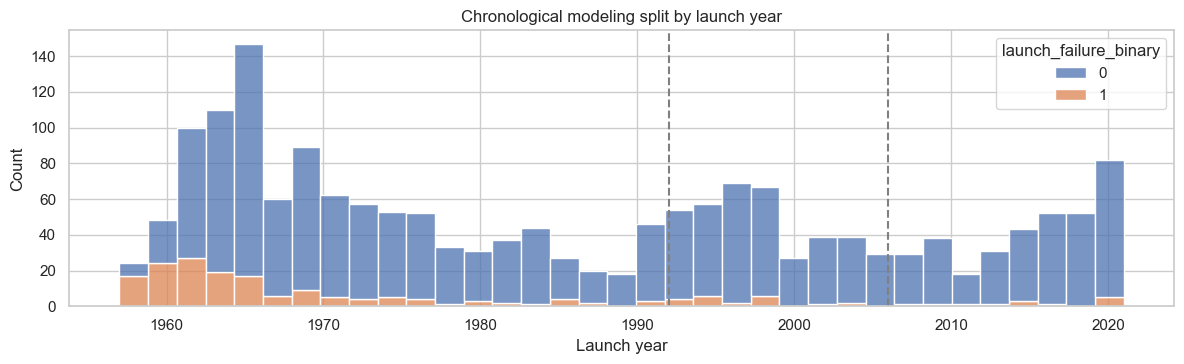

In [111]:
plt.figure(figsize=(12, 3.8))
sns.histplot(data=split_df, x="launch_year", hue="launch_failure_binary", multiple="stack", bins=35)
plt.axvline(train_df["launch_year"].max(), color="gray", linestyle="--", linewidth=1.5)
plt.axvline(val_df["launch_year"].max(), color="gray", linestyle="--", linewidth=1.5)
plt.title("Chronological modeling split by launch year")
plt.xlabel("Launch year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 4. Shared Modeling Utilities


In [112]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_preprocessor = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_preprocessor = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_preprocessor, numeric_features),
            ("cat", categorical_preprocessor, categorical_features),
        ]
    )


class_weights = compute_class_weight(
    "balanced",
    classes=np.array([0, 1]),
    y=train_df["launch_failure_binary"],
)
class_weight_map = {0: class_weights[0], 1: class_weights[1]}
failure_scale_pos_weight = (
    (train_df["launch_failure_binary"] == 0).sum()
    / max((train_df["launch_failure_binary"] == 1).sum(), 1)
)

print("Training class weights:", class_weight_map)
print("XGBoost scale_pos_weight:", round(failure_scale_pos_weight, 3))


def choose_threshold(y_true, proba, thresholds=np.linspace(0.05, 0.95, 181)):
    rows = []
    for threshold in thresholds:
        pred = (proba >= threshold).astype(int)
        rows.append(
            {
                "threshold": threshold,
                "balanced_accuracy": balanced_accuracy_score(y_true, pred),
                "failure_f1": f1_score(y_true, pred, zero_division=0),
                "failure_precision": precision_score(y_true, pred, zero_division=0),
                "failure_recall": recall_score(y_true, pred, zero_division=0),
            }
        )
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values(
        ["balanced_accuracy", "failure_f1", "failure_recall"],
        ascending=False,
    ).iloc[0]
    return float(best_row["threshold"]), threshold_df


def metric_frame(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "failure_precision": precision_score(y_true, pred, zero_division=0),
        "failure_recall": recall_score(y_true, pred, zero_division=0),
        "failure_f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "brier_score": brier_score_loss(y_true, proba),
    }


def transformed_feature_names(fitted_preprocessor):
    return fitted_preprocessor.get_feature_names_out()


def plot_model_diagnostics(name, y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    fpr, tpr, _ = roc_curve(y_true, proba)
    axes[0].plot(fpr, tpr, color="#4e79a7", label=f"AUC = {roc_auc_score(y_true, proba):.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_title(f"{name}: ROC Curve")
    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")
    axes[0].legend(loc="lower right")

    precision, recall, _ = precision_recall_curve(y_true, proba)
    axes[1].plot(recall, precision, color="#f28e2b", label=f"AP = {average_precision_score(y_true, proba):.3f}")
    axes[1].set_title(f"{name}: Precision-Recall Curve")
    axes[1].set_xlabel("Failure recall")
    axes[1].set_ylabel("Failure precision")
    axes[1].legend(loc="upper right")

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        pred,
        ax=axes[2],
        display_labels=["Success", "Not Success"],
        cmap="Blues",
        colorbar=False,
    )
    axes[2].set_title(f"{name}: Confusion Matrix @ {threshold:.2f}")

    plt.tight_layout()
    plt.show()


def plot_calibration_comparison(probability_map, y_true, n_bins=8):
    plt.figure(figsize=(6.5, 5))
    for model_name, proba in probability_map.items():
        frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=n_bins, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker="o", linewidth=1.8, label=model_name)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("Mean predicted failure probability")
    plt.ylabel("Observed failure share")
    plt.title("Calibration on chronological test split")
    plt.legend()
    plt.tight_layout()
    plt.show()


def subgroup_metric_table(y_true, proba, group_values, threshold, min_group_size=20):
    df_group = pd.DataFrame({"group": group_values, "y_true": y_true, "proba": proba}).dropna(subset=["group"])
    rows = []
    for group_name, group_df in df_group.groupby("group"):
        if len(group_df) < min_group_size or group_df["y_true"].nunique() < 2:
            continue
        rows.append(
            {
                "group": group_name,
                "rows": len(group_df),
                "failure_rate": group_df["y_true"].mean(),
                **metric_frame(group_df["y_true"], group_df["proba"], threshold),
            }
        )
    return pd.DataFrame(rows).sort_values("balanced_accuracy", ascending=False)


def fit_and_score_model(model_name, estimator, numeric_features, categorical_features):
    feature_columns = numeric_features + categorical_features
    preprocessor = build_preprocessor(numeric_features, categorical_features)
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    X_train = train_df[feature_columns]
    y_train = train_df["launch_failure_binary"]
    X_val = val_df[feature_columns]
    y_val = val_df["launch_failure_binary"]
    X_test = test_df[feature_columns]
    y_test = test_df["launch_failure_binary"]

    pipe.fit(X_train, y_train)
    val_proba = pipe.predict_proba(X_val)[:, 1]
    threshold, threshold_scan = choose_threshold(y_val, val_proba)
    test_proba = pipe.predict_proba(X_test)[:, 1]

    rows = [
        {"model": model_name, "split": "validation", **metric_frame(y_val, val_proba, threshold)},
        {"model": model_name, "split": "test", **metric_frame(y_test, test_proba, threshold)},
    ]

    return {
        "pipe": pipe,
        "rows": rows,
        "threshold": threshold,
        "threshold_scan": threshold_scan,
        "val_proba": val_proba,
        "test_proba": test_proba,
        "feature_columns": feature_columns,
    }


Training class weights: {0: np.float64(0.5834242093784079), 1: np.float64(3.496732026143791)}
XGBoost scale_pos_weight: 5.993


## 5. Logistic Ablation Under Chronological Evaluation

The main question is whether the richer time-safe features and the site/era interaction structure improve a simple, interpretable model.


In [113]:
ablation_rows = []
ablation_outputs = {}

for feature_set_name, (numeric_features, categorical_features) in feature_sets.items():
    result = fit_and_score_model(
        model_name=f"Logistic | {feature_set_name}",
        estimator=LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            C=0.35,
            solver="lbfgs",
            random_state=RANDOM_STATE,
        ),
        numeric_features=numeric_features,
        categorical_features=categorical_features,
    )
    ablation_rows.extend(result["rows"])
    ablation_outputs[feature_set_name] = result

ablation_df = pd.DataFrame(ablation_rows).sort_values(
    ["split", "balanced_accuracy", "pr_auc"],
    ascending=[True, False, False],
)
ablation_df


,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
1,Logistic | baseline_random_style,test,0.380,0.901961,0.690072,0.176471,0.461538,0.255319,0.867174,0.225789,0.064720
3,Logistic | improved_chrono,test,0.390,0.823529,0.686382,0.109375,0.538462,0.181818,0.768336,0.391995,0.112397
5,Logistic | improved_chrono_with_context,test,0.295,0.719888,0.669611,0.077670,0.615385,0.137931,0.753131,0.391332,0.104087
0,Logistic | baseline_random_style,validation,0.380,0.761905,0.650298,0.127907,0.523810,0.205607,0.664966,0.150090,0.108183
4,Logistic | improved_chrono_with_context,validation,0.295,0.677871,0.627976,0.101695,0.571429,0.172662,0.622874,0.139436,0.107684
2,Logistic | improved_chrono,validation,0.390,0.803922,0.605655,0.123077,0.380952,0.186047,0.611678,0.149047,0.110174


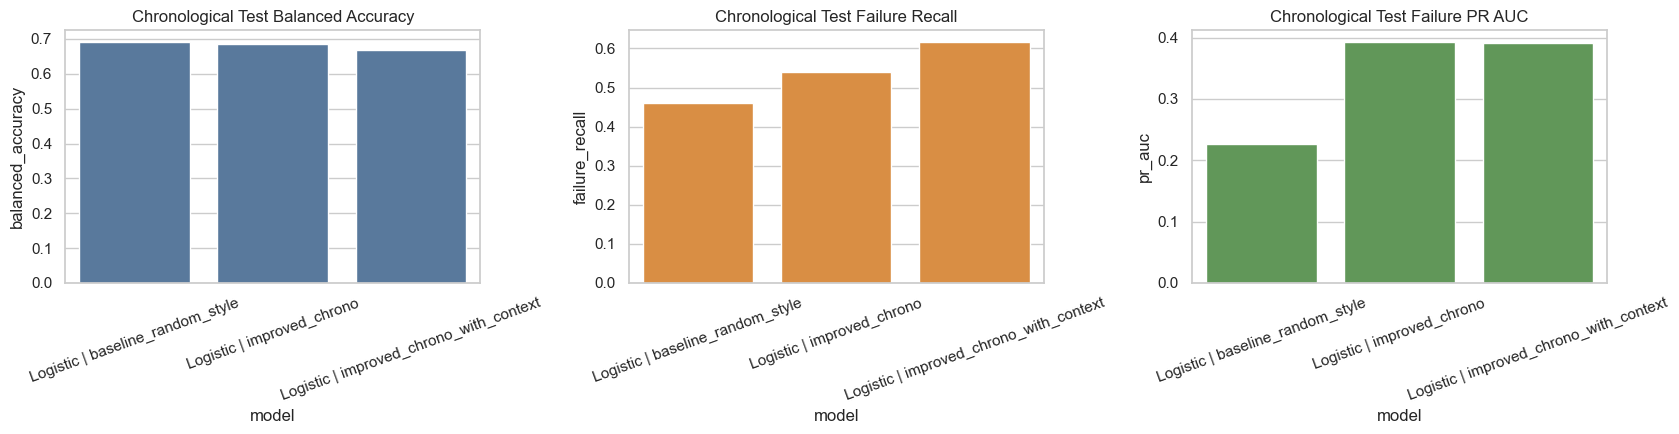

In [114]:
test_ablation = ablation_df[ablation_df["split"] == "test"].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.barplot(data=test_ablation, x="model", y="balanced_accuracy", ax=axes[0], color="#4e79a7")
axes[0].set_title("Chronological Test Balanced Accuracy")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=test_ablation, x="model", y="failure_recall", ax=axes[1], color="#f28e2b")
axes[1].set_title("Chronological Test Failure Recall")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=test_ablation, x="model", y="pr_auc", ax=axes[2], color="#59a14f")
axes[2].set_title("Chronological Test Failure PR AUC")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [115]:
selected_feature_set_name = (
    ablation_df[ablation_df["split"] == "validation"]
    .sort_values(["balanced_accuracy", "pr_auc", "failure_f1"], ascending=False)
    .iloc[0]["model"]
    .split(" | ", 1)[1]
)

selected_numeric_features, selected_categorical_features = feature_sets[selected_feature_set_name]
selected_feature_columns = selected_numeric_features + selected_categorical_features

print("Selected chronological feature set:", selected_feature_set_name)
pd.DataFrame({"selected_numeric_features": selected_numeric_features})


Selected chronological feature set: baseline_random_style


,selected_numeric_features
0,family_success_rate_prelaunch
1,org_success_rate_prelaunch
2,config_success_rate_prelaunch
3,site_launches_so_far
4,family_launches_so_far
5,config_strap_ons
6,config_rocket_height
7,config_liftoff_thrust
8,config_stages
9,mission_mass


#### What this shows

This section directly tests the main recommendation. If the improved feature sets outperform the baseline under chronological evaluation, then the changes are actually helping with out-of-time generalization rather than just fitting a random split.


## 6. Final Model Comparison On The Improved Chronological Setup

The final comparison keeps the better feature set fixed, then compares:

1. Dummy baseline
2. Logistic regression with the improved features
3. XGBoost with the improved features


In [116]:
benchmark_rows = []
model_outputs = {}

dummy_feature_columns = selected_feature_columns
dummy_preprocessor = build_preprocessor(selected_numeric_features, selected_categorical_features)
dummy_pipe = Pipeline(
    steps=[
        ("preprocessor", clone(dummy_preprocessor)),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)

dummy_pipe.fit(train_df[dummy_feature_columns], train_df["launch_failure_binary"])
dummy_val_proba = dummy_pipe.predict_proba(val_df[dummy_feature_columns])[:, 1]
dummy_test_proba = dummy_pipe.predict_proba(test_df[dummy_feature_columns])[:, 1]
dummy_threshold = 0.50

benchmark_rows.extend(
    [
        {
            "model": "Dummy baseline",
            "split": "validation",
            **metric_frame(val_df["launch_failure_binary"], dummy_val_proba, dummy_threshold),
        },
        {
            "model": "Dummy baseline",
            "split": "test",
            **metric_frame(test_df["launch_failure_binary"], dummy_test_proba, dummy_threshold),
        },
    ]
)

model_outputs["Dummy baseline"] = {
    "pipe": dummy_pipe,
    "threshold": dummy_threshold,
    "val_proba": dummy_val_proba,
    "test_proba": dummy_test_proba,
}

pd.DataFrame(benchmark_rows)


,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
0,Dummy baseline,validation,0.5,0.941176,0.5,0.0,0.0,0.0,0.5,0.058824,0.058824
1,Dummy baseline,test,0.5,0.963585,0.5,0.0,0.0,0.0,0.5,0.036415,0.036415


In [117]:
logit_result = fit_and_score_model(
    model_name="Logistic regression",
    estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        C=0.35,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    numeric_features=selected_numeric_features,
    categorical_features=selected_categorical_features,
)

benchmark_rows.extend(logit_result["rows"])
model_outputs["Logistic regression"] = logit_result

pd.DataFrame(benchmark_rows).query("model == 'Logistic regression'")


,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
2,Logistic regression,validation,0.38,0.761905,0.650298,0.127907,0.523810,0.205607,0.664966,0.150090,0.108183
3,Logistic regression,test,0.38,0.901961,0.690072,0.176471,0.461538,0.255319,0.867174,0.225789,0.064720


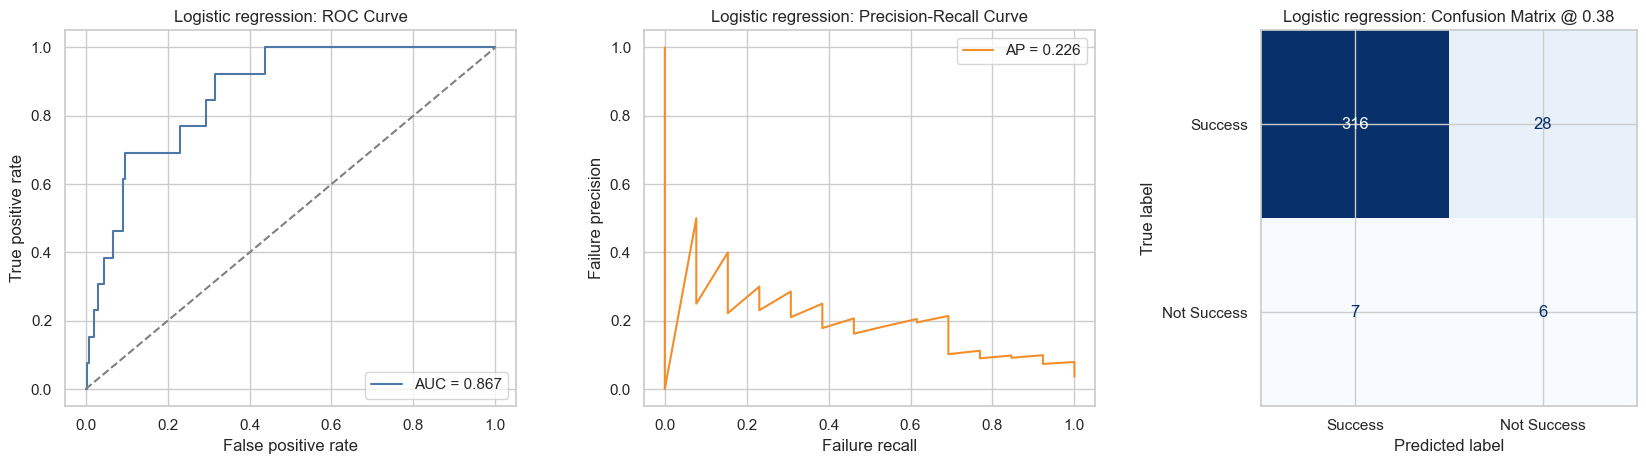

In [118]:
plot_model_diagnostics(
    "Logistic regression",
    test_df["launch_failure_binary"],
    logit_result["test_proba"],
    logit_result["threshold"],
)


In [119]:
logit_result["threshold_scan"].sort_values("balanced_accuracy", ascending=False).head(10)


,threshold,balanced_accuracy,failure_f1,failure_precision,failure_recall
66,0.380,0.650298,0.205607,0.127907,0.523810
67,0.385,0.650298,0.205607,0.127907,0.523810
65,0.375,0.647321,0.201835,0.125000,0.523810
64,0.370,0.644345,0.198198,0.122222,0.523810
36,0.230,0.639881,0.164835,0.093168,0.714286
63,0.365,0.638393,0.191304,0.117021,0.523810
40,0.250,0.633929,0.165680,0.094595,0.666667
51,0.305,0.633929,0.171053,0.099237,0.619048
35,0.225,0.632440,0.160428,0.090361,0.714286
62,0.360,0.630952,0.183333,0.111111,0.523810


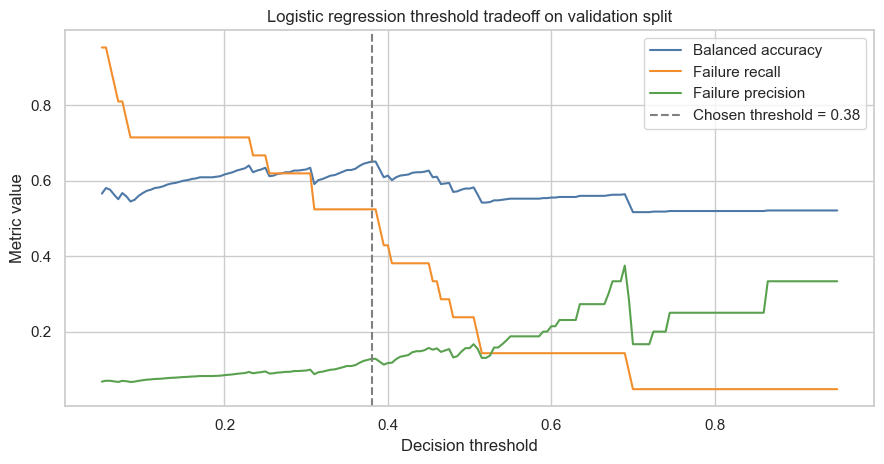

In [120]:
logit_scan_plot = logit_result["threshold_scan"].copy()

plt.figure(figsize=(9, 4.8))
sns.lineplot(data=logit_scan_plot, x="threshold", y="balanced_accuracy", label="Balanced accuracy", color="#4e79a7")
sns.lineplot(data=logit_scan_plot, x="threshold", y="failure_recall", label="Failure recall", color="#f28e2b")
sns.lineplot(data=logit_scan_plot, x="threshold", y="failure_precision", label="Failure precision", color="#59a14f")
plt.axvline(
    logit_result["threshold"],
    linestyle="--",
    color="gray",
    label=f"Chosen threshold = {logit_result['threshold']:.2f}",
)
plt.title("Logistic regression threshold tradeoff on validation split")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.legend()
plt.tight_layout()
plt.show()


#### How to interpret the threshold output

The threshold table and chart show the operational tradeoff directly:

- Lower thresholds catch more failures but create more false alarms.
- Higher thresholds improve precision but miss more true failures.
- The chosen threshold near **0.38** is below the default `0.50`, which means the model must be more willing to flag elevated risk in order to recover the minority class.

For this project that is a reasonable choice. The problem is asymmetric: missing a real failure is generally more costly than flagging an extra launch for additional scrutiny.


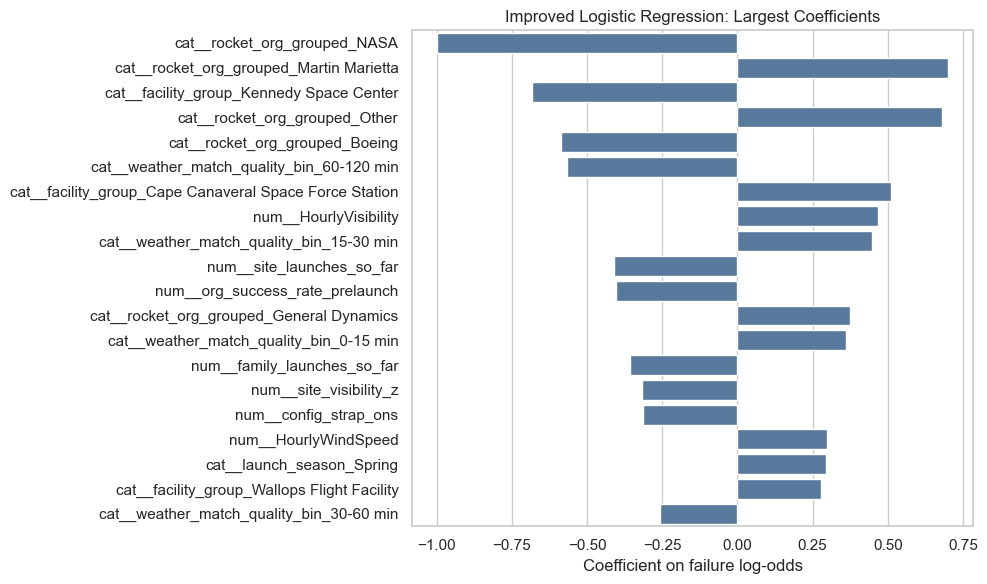

,feature,coefficient,abs_coefficient
35,cat__rocket_org_grouped_NASA,-0.998605,0.998605
34,cat__rocket_org_grouped_Martin Marietta,0.699492,0.699492
27,cat__facility_group_Kennedy Space Center,-0.683020,0.683020
37,cat__rocket_org_grouped_Other,0.680692,0.680692
32,cat__rocket_org_grouped_Boeing,-0.588431,0.588431
50,cat__weather_match_quality_bin_60-120 min,-0.566518,0.566518
24,cat__facility_group_Cape Canaveral Space Force...,0.510612,0.510612
13,num__HourlyVisibility,0.466724,0.466724
48,cat__weather_match_quality_bin_15-30 min,0.447224,0.447224
3,num__site_launches_so_far,-0.412174,0.412174


In [121]:
logit_model = logit_result["pipe"].named_steps["model"]
logit_feature_names = transformed_feature_names(logit_result["pipe"].named_steps["preprocessor"])
logit_coef = pd.DataFrame(
    {
        "feature": logit_feature_names,
        "coefficient": logit_model.coef_[0],
        "abs_coefficient": np.abs(logit_model.coef_[0]),
    }
).sort_values("abs_coefficient", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=logit_coef.head(20), x="coefficient", y="feature", color="#4e79a7")
plt.title("Improved Logistic Regression: Largest Coefficients")
plt.xlabel("Coefficient on failure log-odds")
plt.ylabel("")
plt.tight_layout()
plt.show()

logit_coef.head(20)


#### What this shows

The important question here is whether the strongest logistic coefficients now lean more on time-safe maturity/cadence structure and context interactions rather than only on fixed identity effects. If they do, the model has become more portable and more aligned with the project’s causal story.


#### How to read the coefficient plot

The coefficient chart should be interpreted directionally, not causally:

- Large **negative** coefficients push predictions toward success.
- Large **positive** coefficients push predictions toward not-success.
- Categorical coefficients are relative to omitted baseline categories, so they are best read as context markers rather than literal causal effects.

In context, it is encouraging that historical reliability variables and launch-history depth still appear near the top. At the same time, the presence of strong organization and facility coefficients suggests that part of the model is still capturing persistent ecosystem differences, not just generic physical launch risk.


In [122]:
xgb_result = fit_and_score_model(
    model_name="XGBoost",
    estimator=XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=failure_scale_pos_weight,
        random_state=RANDOM_STATE,
        tree_method="hist",
    ),
    numeric_features=selected_numeric_features,
    categorical_features=selected_categorical_features,
)

benchmark_rows.extend(xgb_result["rows"])
model_outputs["XGBoost"] = xgb_result

pd.DataFrame(benchmark_rows).query("model == 'XGBoost'")


,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
4,XGBoost,validation,0.135,0.879552,0.623512,0.194444,0.333333,0.245614,0.602749,0.175834,0.058279
5,XGBoost,test,0.135,0.761905,0.617397,0.071429,0.461538,0.123711,0.623658,0.170736,0.046655


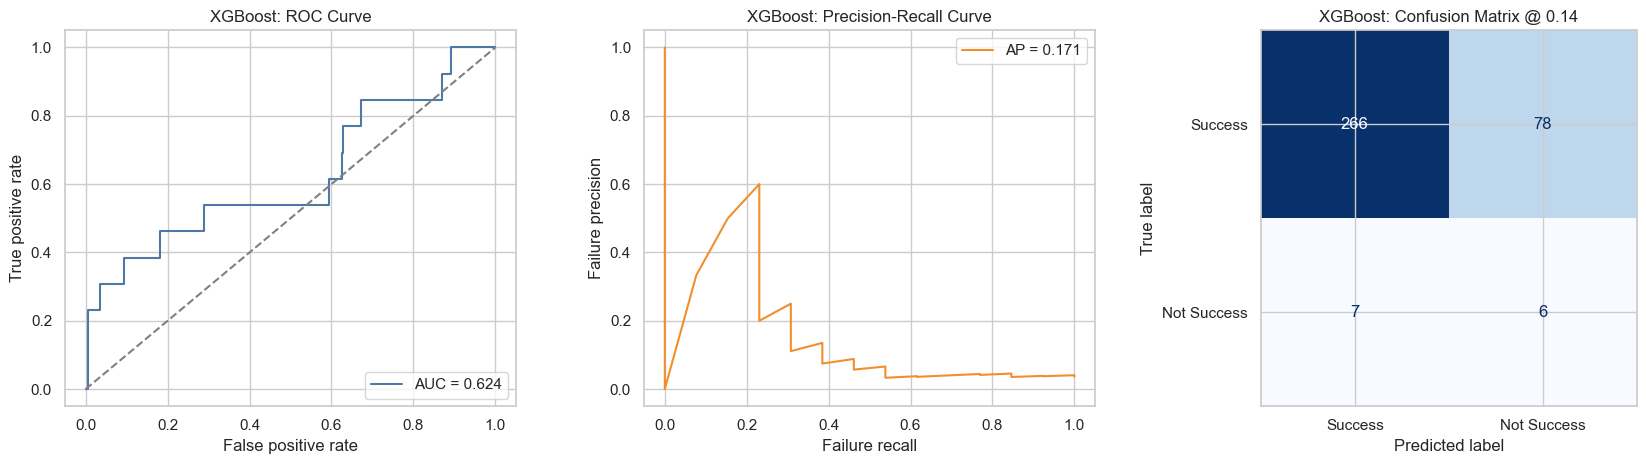

In [123]:
plot_model_diagnostics(
    "XGBoost",
    test_df["launch_failure_binary"],
    xgb_result["test_proba"],
    xgb_result["threshold"],
)


In [124]:
xgb_result["threshold_scan"].sort_values("balanced_accuracy", ascending=False).head(10)


,threshold,balanced_accuracy,failure_f1,failure_precision,failure_recall
17,0.135,0.623512,0.245614,0.194444,0.333333
8,0.090,0.622024,0.213333,0.148148,0.380952
16,0.130,0.619048,0.233333,0.179487,0.333333
7,0.085,0.619048,0.207792,0.142857,0.380952
15,0.125,0.619048,0.233333,0.179487,0.333333
28,0.190,0.616071,0.266667,0.250000,0.285714
27,0.185,0.616071,0.266667,0.250000,0.285714
23,0.165,0.614583,0.260870,0.240000,0.285714
24,0.170,0.614583,0.260870,0.240000,0.285714
25,0.175,0.614583,0.260870,0.240000,0.285714


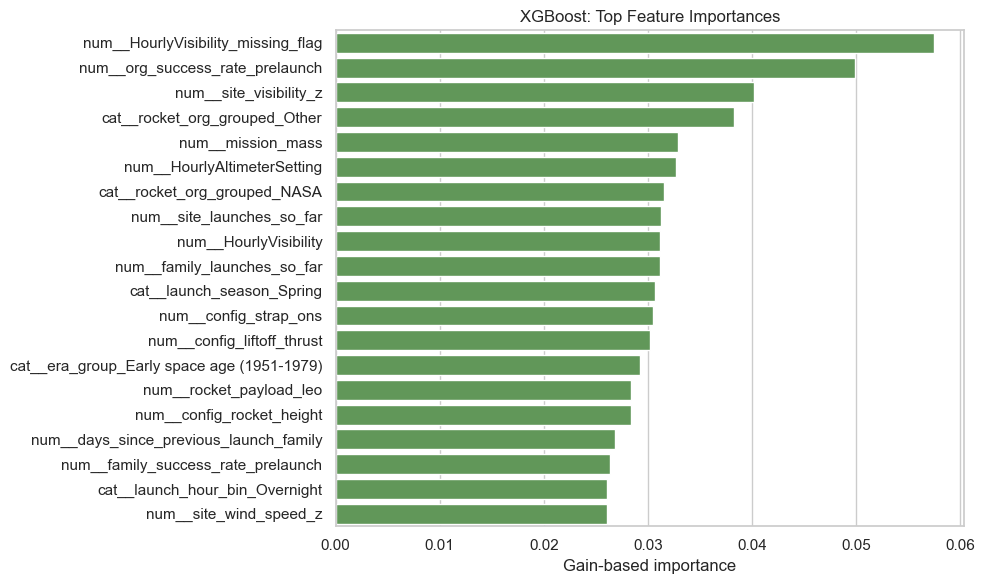

,feature,importance
22,num__HourlyVisibility_missing_flag,0.057522
1,num__org_success_rate_prelaunch,0.049901
14,num__site_visibility_z,0.040213
37,cat__rocket_org_grouped_Other,0.038257
9,num__mission_mass,0.032929
15,num__HourlyAltimeterSetting,0.032683
35,cat__rocket_org_grouped_NASA,0.031556
3,num__site_launches_so_far,0.031280
13,num__HourlyVisibility,0.031207
4,num__family_launches_so_far,0.031157


In [125]:
xgb_importance = pd.DataFrame(
    {
        "feature": transformed_feature_names(xgb_result["pipe"].named_steps["preprocessor"]),
        "importance": xgb_result["pipe"].named_steps["model"].feature_importances_,
    }
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance.head(20), x="importance", y="feature", color="#59a14f")
plt.title("XGBoost: Top Feature Importances")
plt.xlabel("Gain-based importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

xgb_importance.head(20)


#### How to read the XGBoost importance plot

These importances show which inputs the boosted trees relied on most, but they do **not** show direction the way logistic coefficients do. The useful question is whether similar themes keep appearing across model classes. Here they do: visibility, missingness indicators, organizational reliability, launch maturity, and vehicle scale continue to matter, which increases confidence that those signals are real rather than model-specific artifacts.


## 7. Final Comparison, Calibration, And Robustness


In [126]:
benchmark_df = pd.DataFrame(benchmark_rows).sort_values(
    ["split", "balanced_accuracy", "pr_auc"],
    ascending=[True, False, False],
)
benchmark_df


,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
3,Logistic regression,test,0.380,0.901961,0.690072,0.176471,0.461538,0.255319,0.867174,0.225789,0.064720
5,XGBoost,test,0.135,0.761905,0.617397,0.071429,0.461538,0.123711,0.623658,0.170736,0.046655
1,Dummy baseline,test,0.500,0.963585,0.500000,0.000000,0.000000,0.000000,0.500000,0.036415,0.036415
2,Logistic regression,validation,0.380,0.761905,0.650298,0.127907,0.523810,0.205607,0.664966,0.150090,0.108183
4,XGBoost,validation,0.135,0.879552,0.623512,0.194444,0.333333,0.245614,0.602749,0.175834,0.058279
0,Dummy baseline,validation,0.500,0.941176,0.500000,0.000000,0.000000,0.000000,0.500000,0.058824,0.058824


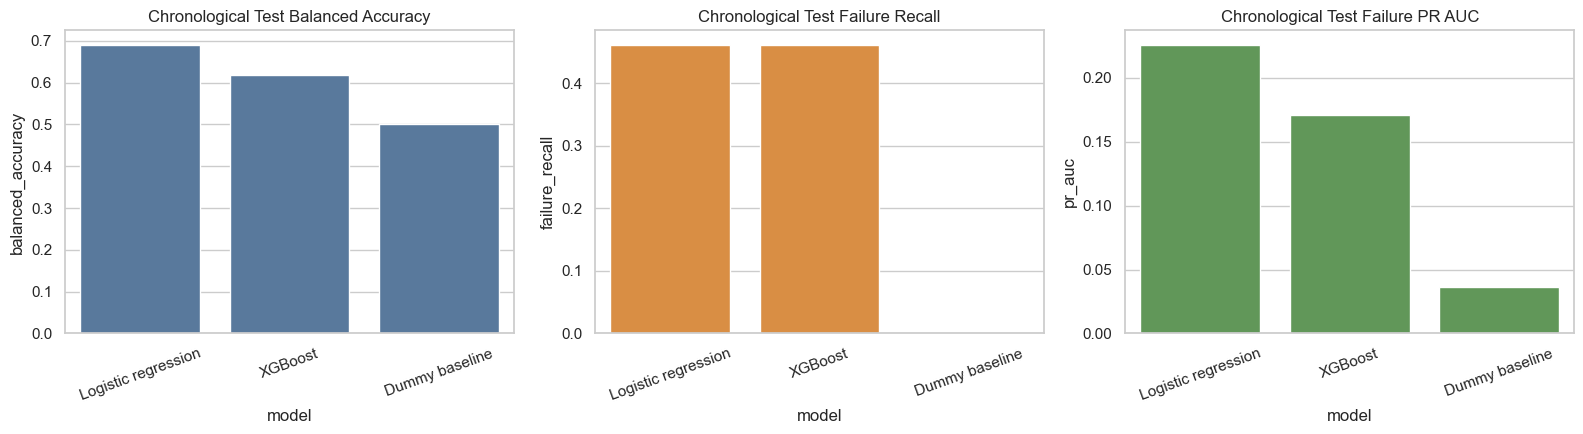

In [127]:
test_benchmark = benchmark_df[benchmark_df["split"] == "test"].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(data=test_benchmark, x="model", y="balanced_accuracy", ax=axes[0], color="#4e79a7")
axes[0].set_title("Chronological Test Balanced Accuracy")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=test_benchmark, x="model", y="failure_recall", ax=axes[1], color="#f28e2b")
axes[1].set_title("Chronological Test Failure Recall")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=test_benchmark, x="model", y="pr_auc", ax=axes[2], color="#59a14f")
axes[2].set_title("Chronological Test Failure PR AUC")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


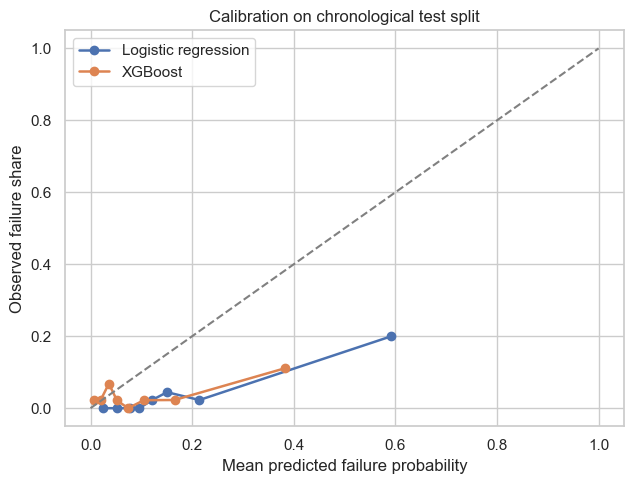

In [128]:
plot_calibration_comparison(
    {
        model_name: output["test_proba"]
        for model_name, output in model_outputs.items()
        if model_name != "Dummy baseline"
    },
    test_df["launch_failure_binary"],
)


#### How to interpret calibration here

Calibration answers a different question than classification metrics. Instead of asking whether the model guessed the class correctly at a single threshold, it asks whether the predicted probabilities are numerically believable.

That matters in this project because the model is more useful as a **risk-ranking and screening tool** than as a hard deterministic classifier. A model with reasonable calibration can still be valuable for prioritization even when failure prediction remains difficult.


In [129]:
best_test_model_name = (
    test_benchmark.sort_values(["balanced_accuracy", "pr_auc", "failure_f1"], ascending=False)
    .iloc[0]["model"]
)
best_test_output = model_outputs[best_test_model_name]

print("Best chronological test model:", best_test_model_name)
print("Threshold:", round(best_test_output["threshold"], 3))


Best chronological test model: Logistic regression
Threshold: 0.38


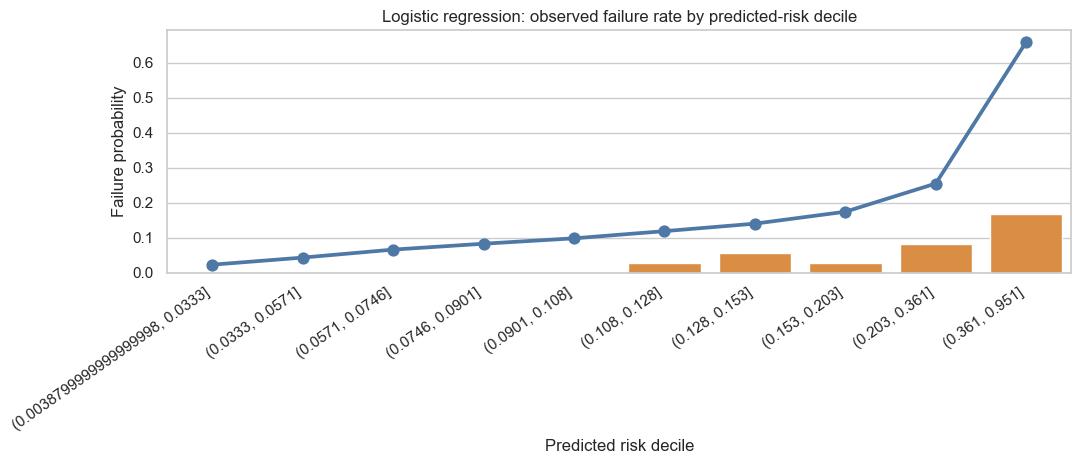

,risk_decile,launches,observed_failure_rate,mean_predicted_risk
0,"(0.0038799999999999998, 0.0333]",36,0.000000,0.022905
1,"(0.0333, 0.0571]",36,0.000000,0.043206
2,"(0.0571, 0.0746]",35,0.000000,0.065970
3,"(0.0746, 0.0901]",36,0.000000,0.082809
4,"(0.0901, 0.108]",36,0.000000,0.098193
5,"(0.108, 0.128]",35,0.028571,0.118684
6,"(0.128, 0.153]",36,0.055556,0.140102
7,"(0.153, 0.203]",35,0.028571,0.174120
8,"(0.203, 0.361]",36,0.083333,0.254640
9,"(0.361, 0.951]",36,0.166667,0.658966


In [130]:
best_model_test_df = test_df.copy()
best_model_test_df["predicted_failure_probability"] = best_test_output["test_proba"]
best_model_test_df["risk_decile"] = pd.qcut(
    best_model_test_df["predicted_failure_probability"],
    q=10,
    duplicates="drop",
)

risk_bucket_summary = (
    best_model_test_df.groupby("risk_decile", observed=False)
    .agg(
        launches=("Launch Id", "count"),
        observed_failure_rate=("launch_failure_binary", "mean"),
        mean_predicted_risk=("predicted_failure_probability", "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(11, 4.8))
sns.barplot(data=risk_bucket_summary, x="risk_decile", y="observed_failure_rate", color="#f28e2b")
sns.pointplot(
    data=risk_bucket_summary,
    x="risk_decile",
    y="mean_predicted_risk",
    color="#4e79a7",
    linestyles="-",
    markers="o",
)
plt.title(f"{best_test_model_name}: observed failure rate by predicted-risk decile")
plt.xlabel("Predicted risk decile")
plt.ylabel("Failure probability")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

risk_bucket_summary


#### Why the risk-decile plot matters

This is one of the most useful decision-oriented outputs in the notebook. It asks whether the model is at least ranking launches sensibly. If the highest predicted-risk buckets also contain the highest observed failure rates, then the model is useful for triage even if its raw precision at one threshold is modest.

In practical terms, that would mean the model could help identify a smaller set of launches that merit extra review, deeper engineering checks, or more conservative planning.


In [131]:
facility_group_results = subgroup_metric_table(
    test_df["launch_failure_binary"],
    best_test_output["test_proba"],
    test_df["facility_group"],
    best_test_output["threshold"],
    min_group_size=20,
)

era_group_results = subgroup_metric_table(
    test_df["launch_failure_binary"],
    best_test_output["test_proba"],
    test_df["era_group"],
    best_test_output["threshold"],
    min_group_size=20,
)

display(facility_group_results)
display(era_group_results)


,group,rows,failure_rate,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
0,Cape Canaveral Space Force Station,192,0.020833,0.38,0.979167,0.500000,0.000000,0.0,0.000000,0.704787,0.041068,0.033082
2,Wallops Flight Facility,23,0.043478,0.38,0.043478,0.500000,0.043478,1.0,0.083333,0.136364,0.050000,0.436811
1,Vandenberg Space Force Base,71,0.042254,0.38,0.943662,0.492647,0.000000,0.0,0.000000,0.955882,0.383333,0.034048


,group,rows,failure_rate,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
0,Modern era (2000-2024),357,0.036415,0.38,0.901961,0.690072,0.176471,0.461538,0.255319,0.867174,0.225789,0.06472


#### How to interpret subgroup results

The subgroup tables are mainly a robustness check:

- If performance collapses in one context, the model may be relying on shortcuts that do not transfer.
- If results are broadly similar, the model is more likely capturing generalizable structure.

These outputs should still be read cautiously because the modern test period contains very few failures, especially within individual facilities. That makes the subgroup results better for spotting obvious instability than for making strong claims about site-specific model quality.


In [132]:
(benchmark_df.round(4)).to_csv(DATA_DIR / "model_benchmark_results.csv", index=False)
benchmark_df.round(4)


,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
3,Logistic regression,test,0.380,0.9020,0.6901,0.1765,0.4615,0.2553,0.8672,0.2258,0.0647
5,XGBoost,test,0.135,0.7619,0.6174,0.0714,0.4615,0.1237,0.6237,0.1707,0.0467
1,Dummy baseline,test,0.500,0.9636,0.5000,0.0000,0.0000,0.0000,0.5000,0.0364,0.0364
2,Logistic regression,validation,0.380,0.7619,0.6503,0.1279,0.5238,0.2056,0.6650,0.1501,0.1082
4,XGBoost,validation,0.135,0.8796,0.6235,0.1944,0.3333,0.2456,0.6027,0.1758,0.0583
0,Dummy baseline,validation,0.500,0.9412,0.5000,0.0000,0.0000,0.0000,0.5000,0.0588,0.0588


#### Interpretation

This notebook now answers a harder and more useful question than the earlier version: can a model trained on earlier launches generalize to later launches once we give it better time-safe maturity and cadence features? If the improved logistic model remains competitive under this setup, that is strong evidence that these structured historical features are the right direction for the project.


#### Final takeaways for the problem as a whole

Several broader conclusions emerge from the full notebook:

1. **Chronological evaluation changes the story.** The task becomes harder once future launches are held out properly, so the earlier random-split results were optimistic.
2. **Historical reliability remains the dominant signal.** Family, organization, configuration, and site maturity continue to explain most of the predictive value.
3. **Weather matters, but mostly as context.** It helps when paired with maturity and site controls rather than serving as a standalone explanation.
4. **Interpretability remains a strength.** Logistic regression still gives the best overall out-of-time tradeoff, which supports a clearer project narrative than a less stable black-box model.

In practical terms, the project supports a defensible conclusion: launch success/failure can be modeled to some extent using prelaunch historical reliability, vehicle configuration, and weather context, but the outputs should be interpreted as probabilistic risk indicators rather than deterministic forecasts.
